# IsolationForest Model Implementation on Mammography Dataset

In [1]:
#importing required modules and libraries
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from sklearn.metrics import(precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix)

In [2]:
# Load the ARFF file
data, meta = arff.loadarff('mammography.arff')
df = pd.DataFrame(data)

# The class column is decoded from byte strings
df['class'] = df['class'].str.decode('utf-8').astype(int)

# Basic shape and structure
print("Shape:", df.shape)
df.head()

Shape: (11183, 7)


,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,-1
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,-1
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,-1
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,-1
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,-1


In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print()
# Class balance (this is our anomaly label)
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True) * 100)
print()
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
attr1    0
attr2    0
attr3    0
attr4    0
attr5    0
attr6    0
class    0
dtype: int64

class
-1    10923
 1      260
Name: count, dtype: int64
class
-1    97.675042
 1     2.324958
Name: proportion, dtype: float64

Duplicate rows: 3334



### Dataset Overview

The Mammography dataset consists of **11,183 samples** and **7 columns**, comprising **6 input features** and **1 target (class) label**.

* **Total samples:** 11,183
* **Features:** 6
* **Target column:** 1 (Class label)
* **Missing values:** None

The dataset is highly imbalanced:

* **Normal instances (`-1`):** 10,923 (~97.68%)
* **Anomalous instances (`1`):** 260 (~2.32%)

This means that anomalies constitute only a small fraction of the dataset, making it well-suited for evaluating anomaly detection algorithms such as **Isolation Forest**.

A total of **3,334 duplicate rows** are present in the dataset. 
___________________________________________________________________________

In [4]:
# Separate features and labels
X = df.drop(columns=['class'])
y_raw = df['class']

# Convert to a common convention: 0 = normal, 1 = anomaly
# (dataset uses -1 = normal, 1 = anomaly)
y = y_raw.map({-1: 0, 1: 1})

# train/test split of dataset
# using 30% data for testing, and stratified split to have same anomaly ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, stratify = y, random_state = 42 )

print("Train shape:", X_train.shape, " Anomaly rate:", y_train.mean())
print("Test shape:", X_test.shape, " Anomaly rate:", y_test.mean())

Train shape: (7828, 6)  Anomaly rate: 0.023249872253449155
Test shape: (3355, 6)  Anomaly rate: 0.02324888226527571


In [5]:
# Parameters for the model
n_estimators = 100
contamination = 0.017
sample_size = 256

# Model initialize and training
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=sample_size, random_state=42, max_features=1.0)
model.fit(X_train)

#prediction of test dataset
preds = model.predict(X_test)
y_pred = pd.Series(preds, index=X_test.index).map({1: 0, -1: 1})

#anomaly score calculation
anomaly_scores = model.decision_function(X_test)

#create dataframe results comprising columns: features, anomaly, anomaly scores, true_label
results = X_test.copy()
results['anomaly_score'] = anomaly_scores
results['anomaly'] = y_pred
results['true_label'] = y_test


In [6]:
# Evaluation
precision = precision_score(y_test,y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, -results['anomaly_score'])

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

Precision: 0.297
Recall:    0.244
F1-score:  0.268
ROC-AUC: 0.862


### Results

* Precision = 0.297
* Recall = 0.244
* F1-Score = 0.268
* ROC-AUC = 0.862

F1-Score is **low**  because:
* Extreme class imbalance punishes F1 disproportionately
* Small feature set (6 features)
____

### Visualisations

**Confusion Matrix**

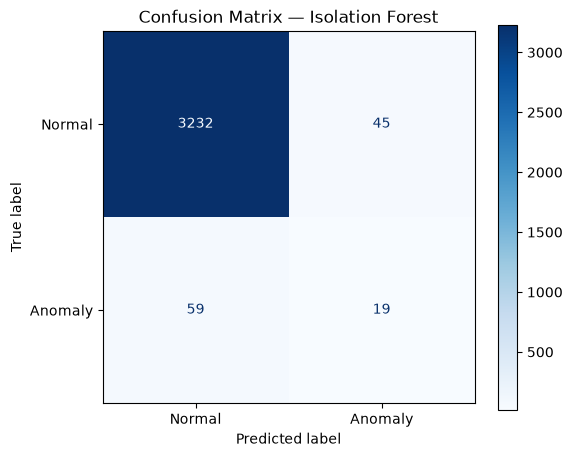

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix — Isolation Forest")
plt.show()

**Anomaly-Score Scatterplot of Data Points**

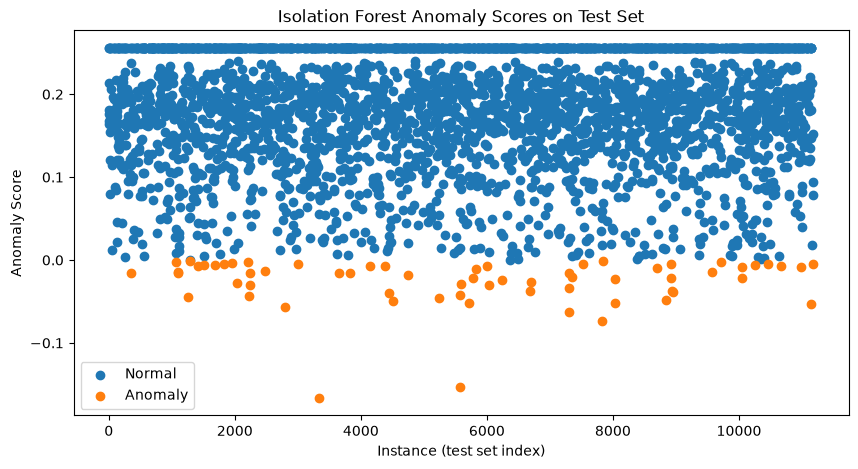

In [8]:
plt.figure(figsize=(10, 5))

# Plot normal data points
normal = results[results['anomaly'] == 0]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = results[results['anomaly'] == 1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly')

plt.xlabel("Instance (test set index)")
plt.ylabel("Anomaly Score")
plt.title("Isolation Forest Anomaly Scores on Test Set")
plt.legend()
plt.show()

**ROC Curve**

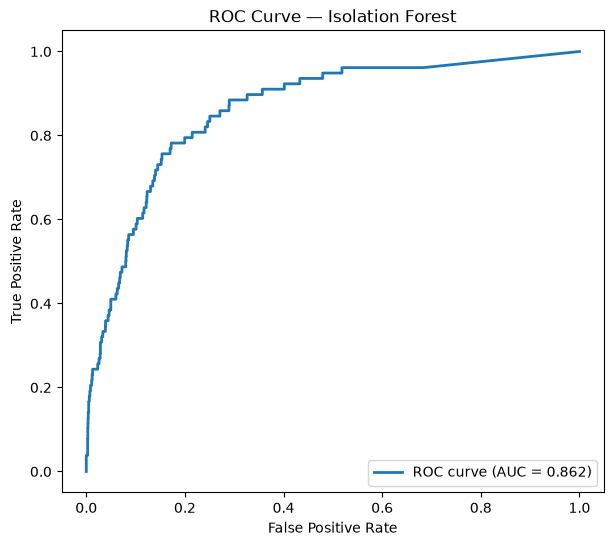

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, -results['anomaly_score'])
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc_val:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Isolation Forest')
plt.legend(loc='lower right')
plt.show()